In [1]:
import os
import pandas as pd
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torch
import torch.optim as optim
import sys
import math

import matplotlib.pyplot as plt
import IPython.display as ipd
import json
from tqdm import tqdm



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importing Dataset

In [3]:
class AudioLanguageDataset(Dataset):
    def __init__(self, csv_file):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the audio files.
        """
        self.audio_db = pd.read_csv(csv_file)

    def __len__(self):
        return len(self.audio_db)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        audio_path = os.path.join(self.audio_db.iloc[idx, 1])
        waveform, sample_rate = torchaudio.load(audio_path)
        gender = self.audio_db.iloc[idx, 4]

        sample = (waveform, sample_rate, gender)

        return sample

In [5]:
train_set = AudioLanguageDataset(csv_file='./gender/train.csv')
dev_set = AudioLanguageDataset(csv_file='./gender/dev.csv')
test_set = AudioLanguageDataset(csv_file='./gender/test.csv')

In [6]:
waveform, sample_rate, label = train_set[0]
print(waveform)
print(sample_rate)
print(label)

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.1035e-05, 3.0518e-05,
         3.0518e-05]])
16000
male


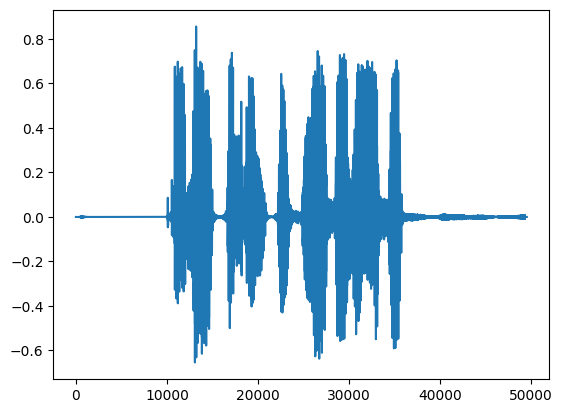

In [7]:
import matplotlib.pyplot as plt
plt.plot(waveform.t().numpy())

In [8]:
waveform_first, _, gender_first = train_set[3]
print(gender_first)


female


In [9]:
ipd.Audio(waveform_first.numpy(), rate=sample_rate)


In [10]:
waveform_second, _, gender_second = train_set[5000]
print(gender_second)

male


In [11]:
ipd.Audio(waveform_second.numpy(), rate=sample_rate)


# Formatting the data

In [12]:

labels = [ "male", "female" ]


In [13]:
len(labels)

2

In [14]:
def label_to_index(word):
    # Return the position of the word in labels
    return torch.tensor(labels.index(word))


def index_to_label(index):
    # Return the word corresponding to the index in labels
    # This is the inverse of label_to_index
    return labels[index]

In [15]:
print(label_to_index('male'))
print(index_to_label(0))

tensor(0)
male


In [16]:
def pad_sequence(batch):
    # Make all tensor in a batch the same length by padding with zeros
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):

    # A data tuple has the form:
    # waveform, sample_rate, label, speaker_id, utterance_number

    tensors, targets = [], []

    # Gather in lists, and encode labels as indices
    for waveform, _, label, *_ in batch:
        tensors += [waveform]
        targets += [label_to_index(label)]

    # Group the list of tensors into a batched tensor
    tensors = pad_sequence(tensors)
    targets = torch.stack(targets)

    return tensors, targets


batch_size = 256

if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

In [17]:
_decibel = 2 * 20 * math.log10(torch.iinfo(torch.int16).max)
_gain = pow(10, 0.05 * _decibel)

def _piecewise_linear_log(x):
    x = x * _gain
    x[x > math.e] = torch.log(x[x > math.e])
    x[x <= math.e] = x[x <= math.e] / math.e
    return x

class FunctionalModule(torch.nn.Module):
    def __init__(self, functional):
        super().__init__()
        self.functional = functional

    def forward(self, input):
        return self.functional(input)


class GlobalStatsNormalization(torch.nn.Module):
    def __init__(self, global_stats_path):
        super().__init__()

        with open(global_stats_path) as f:
            blob = json.loads(f.read())

        self.mean = torch.tensor(blob["mean"])
        self.invstddev = torch.tensor(blob["invstddev"])

    def forward(self, input):
        return (input - self.mean) * self.invstddev

In [18]:
_decibel = 2 * 20 * math.log10(torch.iinfo(torch.int16).max)
_gain = pow(10, 0.05 * _decibel)


class TransfomrFeature(torch.nn.Module):
    def __init__(self, global_stats_path):
        super().__init__()
        self._extra_pipeline = torch.nn.Sequential(
            FunctionalModule(_piecewise_linear_log),
            GlobalStatsNormalization(global_stats_path),
        )
        self._spectrogram_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_fft=400, n_mels=80, hop_length=160)

    def forward(self, waveform):
        mel_features = self._spectrogram_transform(waveform).squeeze(1).transpose(2, 1)
        feats = self._extra_pipeline(mel_features)
        lengths = torch.tensor([elem.shape[0] for elem in mel_features], dtype=torch.int32)
        return feats, lengths

# Define the Network

In [19]:
import sentencepiece as spm
from lightning import ConformerRNNTModule
sp_model_path = 'spm_unigram_1023.model'
sp_model = spm.SentencePieceProcessor(model_file=sp_model_path)


C:\Users\jaeyo\anaconda3\envs\asr\Lib\site-packages\lightning_utilities\core\imports.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [21]:
rnnt_checkpoint_path = './exp/checkpoints/epoch=2-step=42813.ckpt'
rnnt_module = ConformerRNNTModule.load_from_checkpoint(rnnt_checkpoint_path, sp_model=sp_model).eval()

C:\Users\jaeyo\anaconda3\envs\asr\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [22]:
rnnt_module.model.transcriber

_ConformerEncoder(
  (time_reduction): _TimeReduction()
  (input_linear): Linear(in_features=320, out_features=256, bias=True)
  (conformer): Conformer(
    (conformer_layers): ModuleList(
      (0-15): 16 x ConformerLayer(
        (ffn1): _FeedForwardModule(
          (sequential): Sequential(
            (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=256, out_features=1024, bias=True)
            (2): SiLU()
            (3): Dropout(p=0.1, inplace=False)
            (4): Linear(in_features=1024, out_features=256, bias=True)
            (5): Dropout(p=0.1, inplace=False)
          )
        )
        (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (self_attn_dropout): Dropout(p=0.1, inplace=False)
        (conv_module): _ConvolutionModule(
          (l

In [23]:
class ConformerWithAveragePooling(torch.nn.Module):
    def __init__(self, conformer_model, encoder_dim, num_classes):
        super(ConformerWithAveragePooling, self).__init__()
        self.conformer_model = conformer_model
        self.encoder_dim = encoder_dim
        self.classifier = torch.nn.Linear(encoder_dim, num_classes)
        
    def forward(self, input_features: torch.Tensor, input_lengths: torch.Tensor):
        # input_features: [batch_size, seq_len, feature_dim]
        
        # Get Conformer encoder outputs
        encoder_outputs = self.conformer_model(input_features, input_lengths)  # [batch_size, seq_len, encoder_dim]
        
        # Apply average pooling
        # Assuming encoder_outputs is a tensor; if it's a tuple, adjust accordingly
        pooled_output = torch.mean(encoder_outputs[0], dim=1)  # [batch_size, encoder_dim]
        
        # Classification
        logits = self.classifier(pooled_output)  # [batch_size, num_classes]
        
        return logits


In [24]:
model=ConformerWithAveragePooling(conformer_model=rnnt_module.model.transcriber, encoder_dim=1024, num_classes=2)
model.to(device)
print(model)


ConformerWithAveragePooling(
  (conformer_model): _ConformerEncoder(
    (time_reduction): _TimeReduction()
    (input_linear): Linear(in_features=320, out_features=256, bias=True)
    (conformer): Conformer(
      (conformer_layers): ModuleList(
        (0-15): 16 x ConformerLayer(
          (ffn1): _FeedForwardModule(
            (sequential): Sequential(
              (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
              (1): Linear(in_features=256, out_features=1024, bias=True)
              (2): SiLU()
              (3): Dropout(p=0.1, inplace=False)
              (4): Linear(in_features=1024, out_features=256, bias=True)
              (5): Dropout(p=0.1, inplace=False)
            )
          )
          (self_attn_layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (self_attn_dropo

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


n = count_parameters(model)
print("Number of parameters: %s" % n)

Number of parameters: 24716546


In [26]:
for param in model.conformer_model.parameters():
    param.requires_grad=False

n = count_parameters(model)
print("Number of parameters: %s" % n)

Number of parameters: 2050


In [27]:
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)  # reduce the learning after 20 epochs by a factor of 10

# Training and Testing the network

In [28]:
def train(model, epoch, log_interval):
    model.train()
    celoss = torch.nn.CrossEntropyLoss()

    for batch_idx, (data, target) in enumerate(train_loader):

        target = target.to(device)

        # apply transform and model on whole batch directly on device
        feats, lengths = transform(data)

        output = model(feats.to(device), lengths.to(device))
        
        loss = celoss(output.squeeze(), target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # print training stats
        if batch_idx % log_interval == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}")

        # update progress bar
        pbar.update(pbar_update)
        # record loss
        losses.append(loss.item())

In [29]:
def number_of_correct(pred, target):
    # count number of correct predictions
    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):
    # find most likely label index for each element in the batch
    return tensor.argmax(dim=-1)


def test(model, epoch):
    model.eval()
    correct = 0
    for data, target in test_loader:

        target = target.to(device)

        # apply transform and model on whole batch directly on device
        feats, lengths = transform(data)

        feats.to(device)
        lengths.to(device)

        output = model(feats.to(device), lengths.to(device))

        pred = get_likely_index(output)
        correct += number_of_correct(pred, target)

        # update progress bar
        pbar.update(pbar_update)

    print(f"\nTest Epoch: {epoch}\tAccuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n")

In [30]:
log_interval = 20
n_epoch = 20

pbar_update = 1 / (len(train_loader) + len(test_loader))
losses = []

# The transform needs to live on the same device as the model and the data.
transform = TransfomrFeature('./global_stats.json')
with tqdm(total=n_epoch) as pbar:
    for epoch in range(1, n_epoch + 1):
        train(model, epoch, log_interval)
        test(model, epoch)
        scheduler.step()

C:\Users\jaeyo\anaconda3\envs\asr\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)
  0%|                     | 0.018518518518518517/20 [00:04<1:23:13, 249.88s/it]

Train Epoch: 1 [0/9552 (0%)]	Loss: 0.638556


  2%|▍                       | 0.38888888888888873/20 [01:03<57:05, 174.65s/it]

Train Epoch: 1 [5120/9552 (53%)]	Loss: 0.847918


  5%|█▏                       | 0.9999999999999989/20 [02:32<34:13, 108.08s/it]

...


Test Epoch: 4	Accuracy: 3196/3903 (82%)



 20%|█████▍                     | 4.01851851851853/20 [10:09<34:29, 129.52s/it]

Train Epoch: 5 [0/9552 (0%)]	Loss: 0.404224


 21%|█████▍                    | 4.166666666666675/20 [10:34<40:12, 152.39s/it]


KeyboardInterrupt: 

In [38]:
def predict(tensor):
    # Use the model to predict the label of the waveform
    feats, lengths = transform(tensor)
    output = model(feats.to(device), lengths.to(device))
    output = get_likely_index(output)
    output = index_to_label(output.squeeze(0))
    return output

In [39]:
waveform, sample_rate, label, *_ = train_set[5000]


In [40]:
ipd.Audio(waveform.numpy(), rate=sample_rate)


In [41]:
print(predict(waveform), label)


male male


In [42]:
waveform, sample_rate, label, *_ = test_set[500]


In [43]:
ipd.Audio(waveform.numpy(), rate=sample_rate)


In [44]:
print(predict(waveform), label)


male female
